# Custom Transformer from Scratch

Goal:
- Implement Transformer Encoder manually
- No nn.TransformerEncoder
- No nn.MultiheadAttention

Components:
1. Embedding
2. Positional Encoding
3. Scaled Dot Product Attention
4. Multi-Head Attention
5. Feed Forward Network
6. Encoder Block
7. Custom Transformer

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

from pipeline.metrics import evaluate_trading_metrics

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Device : cuda
NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [5]:
baseline_results = pd.read_csv("experiments/baseline_results.csv")
trading_results = pd.read_csv("experiments/trading_results.csv")
experiment_log = pd.read_csv("experiments/experiment_log.csv")

In [7]:
X_train = torch.tensor(np.load("pipeline/X_train.npy"), dtype=torch.float32)
y_train = torch.tensor(np.load("pipeline/y_train.npy"), dtype=torch.float32)

X_val = torch.tensor(np.load("pipeline/X_val.npy"), dtype=torch.float32)
y_val = torch.tensor(np.load("pipeline/y_val.npy"), dtype=torch.float32)

X_test = torch.tensor(np.load("pipeline/X_test.npy"), dtype=torch.float32)
y_test = torch.tensor(np.load("pipeline/y_test.npy"), dtype=torch.float32)

In [8]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(X_test.shape)

torch.Size([1844, 60, 95])
torch.Size([1844])
torch.Size([348, 60, 95])
torch.Size([349, 60, 95])


In [9]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# Model Hyperparameters

In [37]:
INPUT_DIM = X_train.shape[2]
SEQ_LENGTH = X_train.shape[1]

D_MODEL = 128
NUM_HEADS = 8
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.1
EPOCHS = 15
LEARNING_RATE = 1e-3
PATIENCE = 5

In [12]:
print("Features :", NUM_FEATURES)
print("Sequence :", X_train.shape[1])

Features : 95
Sequence : 60


# Positional Encoding

In [13]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )
        pe[:,0::2] = torch.sin(position * div_term)
        pe[:,1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:,:x.size(1)]

In [14]:
sample = PositionalEncoding(D_MODEL)
print(sample.pe.shape)

torch.Size([1, 5000, 128])


# Scaled Dot Product Attention

Given Queries (Q), Keys (K), and Values (V):

Attention(Q,K,V)=Softmax(QKᵀ/√d)V

This computes how much each token attends to every other token.

In [15]:
class ScaledDotProductAttention(nn.Module):

    def __init__(self):
        super().__init__()
    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attention = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention, V)
        return output, attention

In [16]:
attention = ScaledDotProductAttention()
Q = torch.randn(2, 60, 64)
K = torch.randn(2, 60, 64)
V = torch.randn(2, 60, 64)
output, weights = attention(Q, K, V)
print(output.shape)
print(weights.shape)

torch.Size([2, 60, 64])
torch.Size([2, 60, 60])


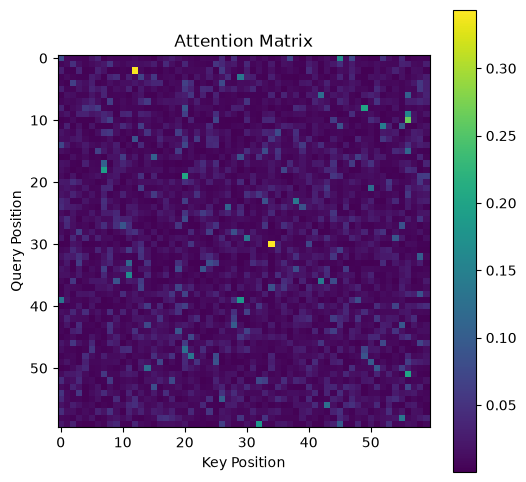

In [17]:
plt.figure(figsize=(6,6))
plt.imshow(weights[0].detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Attention Matrix")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.show()

# Multi-Head Attention

Instead of computing attention once, we compute it multiple times.

Each head learns different relationships:

Head 1 → Short-term patterns

Head 2 → Long-term trends

Head 3 → Volatility

Head 4 → Momentum

...

The outputs are concatenated and projected back into the embedding space.

In [23]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention()
        self.fc = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(
            batch_size,
            -1,
            self.num_heads,
            self.head_dim
        )
        return x.transpose(1, 2)    
    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.transpose(1, 2).contiguous()
        x = x.view(
            batch_size,
            -1,
            self.d_model
        )
        return x  
    def forward(self, x, mask=None):

        Q = self.split_heads(self.Wq(x))
        K = self.split_heads(self.Wk(x))
        V = self.split_heads(self.Wv(x))
        output, weights = self.attention(Q, K, V, mask)
        output = self.combine_heads(output)
        output = self.fc(output)
        return output, weights

In [24]:
mha = MultiHeadAttention(D_MODEL, NUM_HEADS)
dummy = torch.randn(32, 60, D_MODEL)
output, weights = mha(dummy)
print(output.shape)
print(weights.shape)

torch.Size([32, 60, 128])
torch.Size([32, 8, 60, 60])


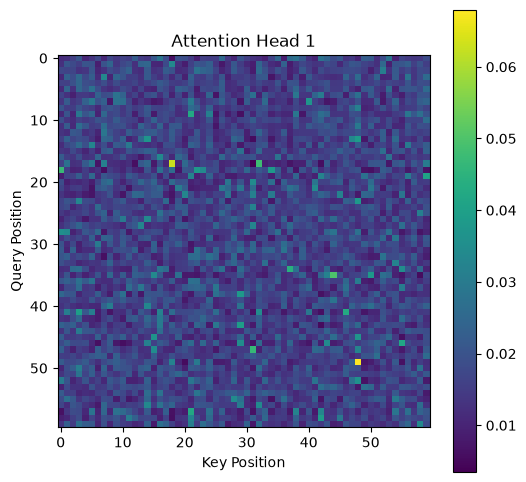

In [25]:
plt.figure(figsize=(6,6))
plt.imshow(weights[0,0].detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Attention Head 1")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.show()

# Position-wise Feed Forward Network

Each token independently passes through a small neural network.

FFN(x) = Linear → GELU → Dropout → Linear

In [26]:
class FeedForward(nn.Module):

    def __init__(self, d_model, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
    def forward(self, x):
        return self.net(x)

In [27]:
ffn = FeedForward(D_MODEL, FF_DIM)
dummy = torch.randn(32, 60, D_MODEL)
out = ffn(dummy)
print(out.shape)

torch.Size([32, 60, 128])


# Transformer Encoder Block

Encoder Block:

Input
 ↓
Multi-Head Attention
 ↓
Residual Connection
 ↓
LayerNorm
 ↓
Feed Forward
 ↓
Residual Connection
 ↓
LayerNorm

In [31]:
class EncoderBlock(nn.Module):

    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, ff_dim, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        attn_output, weights = self.attention(x)
        x = self.norm1(
            x + self.dropout(attn_output)
        )
        ff_output = self.ffn(x)
        x = self.norm2(
            x + self.dropout(ff_output)
        )
        return x, weights

In [32]:
encoder = EncoderBlock(
    D_MODEL,
    NUM_HEADS,
    FF_DIM,
    DROPOUT
)
dummy = torch.randn(32, 60, D_MODEL)
output, weights = encoder(dummy)
print(output.shape)
print(weights.shape)

torch.Size([32, 60, 128])
torch.Size([32, 8, 60, 60])


# Transformer Encoder

Stack multiple encoder blocks together.

Input
 ↓
Linear Projection
 ↓
Positional Encoding
 ↓
Encoder Block × N
 ↓
Pooling
 ↓
Regression Head

In [34]:
class TransformerEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        d_model,
        num_heads,
        ff_dim,
        num_layers,
        dropout=0.1
    ):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.position = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            EncoderBlock(
                d_model,
                num_heads,
                ff_dim,
                dropout
            )
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(d_model, 1)

    def forward(self, x):

        x = self.embedding(x)
        x = self.position(x)
        x = self.dropout(x)
        attention_maps = []
        for layer in self.layers:
            x, attn = layer(x)
            attention_maps.append(attn)
        x = x[:, -1]
        out = self.regressor(x)
        return out.squeeze(-1), attention_maps

In [39]:
model = TransformerEncoder(
    INPUT_DIM,
    D_MODEL,
    NUM_HEADS,
    FF_DIM,
    NUM_LAYERS,
    DROPOUT
).to(DEVICE)

print(model)

TransformerEncoder(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (attention): MultiHeadAttention(
        (Wq): Linear(in_features=128, out_features=128, bias=True)
        (Wk): Linear(in_features=128, out_features=128, bias=True)
        (Wv): Linear(in_features=128, out_features=128, bias=True)
        (attention): ScaledDotProductAttention()
        (fc): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=128, bias=True)
        )
      )
      (dropout): Dropout(p=0.1,

In [41]:
dummy = torch.randn(16, SEQ_LENGTH, INPUT_DIM).to(DEVICE)
pred, attention = model(dummy)
print(pred.shape)
print(len(attention))
print(attention[0].shape)

torch.Size([16])
2
torch.Size([16, 8, 60, 60])


In [42]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters : {total:,}")
print(f"Trainable : {trainable:,}")

Total Parameters : 277,377
Trainable : 277,377


# Loss Function and Optimizer

In [43]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# DataLoaders

In [44]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

C:\Users\User\AppData\Local\Temp\ipykernel_32000\533133048.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_train, dtype=torch.float32),
C:\Users\User\AppData\Local\Temp\ipykernel_32000\533133048.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train, dtype=torch.float32)
C:\Users\User\AppData\Local\Temp\ipykernel_32000\533133048.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_val, dtype=torch.float32),
C:\Users\User\AppData\Local\Temp\ipykernel_32000\533133048.py:7: UserWarning: To c

In [45]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# Training Function

In [46]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred, _ = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [47]:
def validate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            pred, _ = model(X_batch)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(loader)

# Training Loop

In [48]:
best_loss = float("inf")
train_losses = []
val_losses = []
patience_counter = 0

In [50]:
import time


start = time.time()
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss = validate(model, val_loader)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train {train_loss:.6f} | Val {val_loss:.6f}")
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "models/custom_transformer.pth")
    else:
        patience_counter += 1
    if patience_counter >= PATIENCE:
        print("Early stopping")
        break
train_time = time.time() - start
print(f"\nTraining Time : {train_time:.2f} sec")

Epoch 1/15 | Train 0.145680 | Val 0.013847
Epoch 2/15 | Train 0.004588 | Val 0.004680
Epoch 3/15 | Train 0.002995 | Val 0.001878
Epoch 4/15 | Train 0.002445 | Val 0.001157
Epoch 5/15 | Train 0.003085 | Val 0.001074
Epoch 6/15 | Train 0.002158 | Val 0.001405
Epoch 7/15 | Train 0.001825 | Val 0.001027
Epoch 8/15 | Train 0.002069 | Val 0.001055
Epoch 9/15 | Train 0.001956 | Val 0.001030
Epoch 10/15 | Train 0.001747 | Val 0.001114
Epoch 11/15 | Train 0.001857 | Val 0.001293
Epoch 12/15 | Train 0.001781 | Val 0.001009
Epoch 13/15 | Train 0.001655 | Val 0.001021
Epoch 14/15 | Train 0.001708 | Val 0.001139
Epoch 15/15 | Train 0.001655 | Val 0.001629

Training Time : 4.13 sec


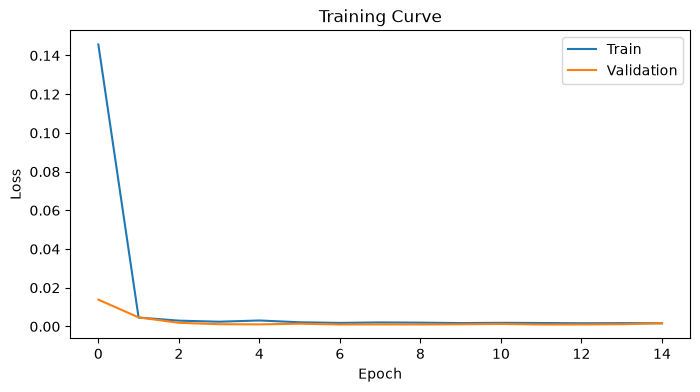

In [51]:
plt.figure(figsize=(8,4))
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

In [52]:
model.load_state_dict(torch.load("models/custom_transformer.pth", map_location=DEVICE))
model.eval()

TransformerEncoder(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (attention): MultiHeadAttention(
        (Wq): Linear(in_features=128, out_features=128, bias=True)
        (Wk): Linear(in_features=128, out_features=128, bias=True)
        (Wv): Linear(in_features=128, out_features=128, bias=True)
        (attention): ScaledDotProductAttention()
        (fc): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=128, bias=True)
        )
      )
      (dropout): Dropout(p=0.1,

In [53]:
predictions = []
targets = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred,_ = model(X_batch)
        predictions.extend(pred.cpu().numpy())
        targets.extend(y_batch.numpy())
predictions = np.array(predictions)
targets = np.array(targets)

In [54]:
mae = mean_absolute_error(targets,predictions)
rmse = np.sqrt(mean_squared_error(targets,predictions))
r2 = r2_score(targets,predictions)
print("MAE :",mae)
print("RMSE:",rmse)
print("R² :",r2)

MAE : 0.03096231259405613
RMSE: 0.043110733456118565
R² : -0.04535329341888428


In [55]:
from pipeline.metrics import evaluate_trading_metrics
transformer_metrics = evaluate_trading_metrics(
    targets,
    predictions
)
transformer_metrics

{'Directional Accuracy': np.float64(0.5214899713467048),
 'Hit Rate': np.float64(0.5214899713467048),
 'Sharpe': np.float64(0.17775985696262664),
 'Strategy Return': np.float32(-0.13939035),
 'Max Drawdown': np.float32(-0.60128015)}

In [56]:
results = pd.DataFrame({
    "Model":["Custom Transformer"],
    "MAE":[mae],
    "RMSE":[rmse],
    "R2":[r2]
})

results

,Model,MAE,RMSE,R2
0,Custom Transformer,0.030962,0.043111,-0.045353


In [57]:
trading_results = pd.DataFrame({
    "Model":["Custom Transformer"],
    "Directional Accuracy":[transformer_metrics["Directional Accuracy"]],
    "Hit Rate":[transformer_metrics["Hit Rate"]],
    "Sharpe":[transformer_metrics["Sharpe"]],
    "Strategy Return":[transformer_metrics["Strategy Return"]],
    "Max Drawdown":[transformer_metrics["Max Drawdown"]]
})

trading_results

,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
0,Custom Transformer,0.52149,0.52149,0.17776,-0.13939,-0.60128


In [58]:
baseline = pd.read_csv("experiments/baseline_results.csv")

baseline.loc[len(baseline)] = [
    "Custom Transformer",
    mae,
    rmse,
    r2
]

baseline.to_csv("experiments/baseline_results.csv", index=False)

baseline

,Model,MAE,RMSE,R2
0,Linear Regression,0.188742,0.248706,-33.790931
1,Random Forest,0.033050,0.045135,-0.145847
2,LSTM,0.040036,0.052256,-0.535912
3,GRU,0.034453,0.047614,-0.275127
4,XGBoost,0.034423,0.045011,-0.139553
5,PyTorch Transformer,0.032234,0.043543,-0.066416
6,Custom Transformer,0.030962,0.043111,-0.045353


In [60]:
trading = pd.read_csv("experiments/trading_results.csv")

trading.loc[len(trading)] = [
    "Custom Transformer",
    transformer_metrics["Directional Accuracy"],
    transformer_metrics["Hit Rate"],
    transformer_metrics["Sharpe"],
    transformer_metrics["Strategy Return"],
    transformer_metrics["Max Drawdown"]
]

trading.to_csv("experiments/trading_results.csv", index=False)

trading

,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
0,Linear Regression,0.467049,0.467049,-0.398144,-0.494425,-0.694398
1,Random Forest,0.515759,0.515759,0.334000,0.001970,-0.675468
2,XGBoost,0.489971,0.489971,-0.132552,-0.350803,-0.741019
3,LSTM,0.478510,0.478510,-0.142696,-0.357364,-0.782726
4,GRU,0.578797,0.578797,2.789059,8.535793,-0.703745
5,PyTorch Transformer,0.441261,0.441261,-0.799614,-0.651581,-0.850522
6,Custom Transformer,0.521490,0.521490,0.177760,-0.139390,-0.601280
7,Custom Transformer,0.521490,0.521490,0.177760,-0.139390,-0.601280


In [61]:
experiment_log = pd.read_csv("experiments/experiment_log.csv")

experiment_log.loc[len(experiment_log)] = {
    "Experiment":"Custom Transformer",
    "Model":"Custom Transformer",
    "Parameters":sum(p.numel() for p in model.parameters()),
    "Train Time (s)":train_time,
    "Epochs":len(train_losses),
    "MAE":mae,
    "RMSE":rmse,
    "R2":r2,
    "Directional Accuracy":transformer_metrics["Directional Accuracy"],
    "Hit Rate":transformer_metrics["Hit Rate"],
    "Sharpe":transformer_metrics["Sharpe"],
    "Strategy Return":transformer_metrics["Strategy Return"],
    "Max Drawdown":transformer_metrics["Max Drawdown"],
    "Notes":"Built completely from scratch"
}

experiment_log.to_csv("experiments/experiment_log.csv", index=False)

experiment_log

,Experiment,Model,Parameters,Train Time (s),Epochs,MAE,RMSE,R2,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown,Notes
0,Baseline,Linear Regression,NaN,NaN,NaN,0.188742,0.248706,-33.790931,0.467049,0.467049,-0.398144,-0.494425,-0.694398,Baseline
1,Baseline,Random Forest,NaN,NaN,NaN,0.033050,0.045135,-0.145847,0.515759,0.515759,0.334000,0.001970,-0.675468,Baseline
2,Baseline,LSTM,NaN,NaN,NaN,0.040036,0.052256,-0.535912,0.489971,0.489971,-0.132552,-0.350803,-0.741019,Baseline
3,Baseline,GRU,NaN,NaN,NaN,0.034453,0.047614,-0.275127,0.478510,0.478510,-0.142696,-0.357364,-0.782726,Baseline
4,Baseline,XGBoost,NaN,NaN,NaN,0.034423,0.045011,-0.139553,0.578797,0.578797,2.789059,8.535793,-0.703745,Baseline
5,Baseline,PyTorch Transformer,813697.0,10.260000,15.0,0.032234,0.043543,-0.066416,0.441261,0.441261,-0.799614,-0.651581,-0.850522,nn.TransformerEncoder
6,Custom Transformer,Custom Transformer,277377.0,4.133688,15.0,0.030962,0.043111,-0.045353,0.521490,0.521490,0.177760,-0.139390,-0.601280,Built completely from scratch


C:\Users\User\AppData\Local\Temp\ipykernel_32000\2972954529.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample = torch.tensor(X_test[:1], dtype=torch.float32).to(DEVICE)


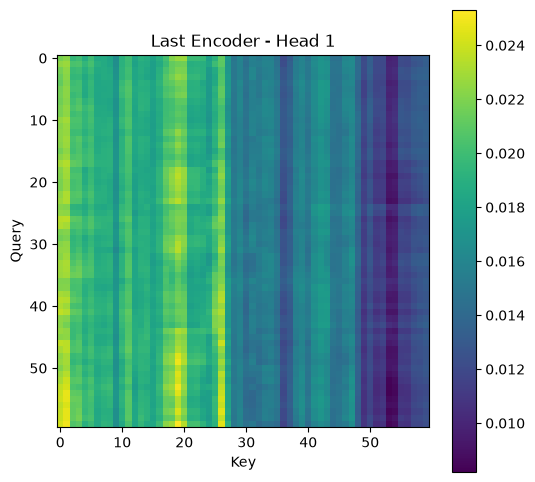

In [62]:
sample = torch.tensor(X_test[:1], dtype=torch.float32).to(DEVICE)

model.eval()

with torch.no_grad():
    _, attention = model(sample)

attn = attention[-1][0,0].cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(attn, cmap="viridis")
plt.colorbar()
plt.title("Last Encoder - Head 1")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()